In [1]:
import pandas as pd
import plotly.express as px

import pydartdiags.obs_sequence.obs_sequence as obsq
from pydartdiags.data import get_example_data

In [2]:
import matplotlib.pyplot as plt

package_dir: /gpfs/home/sa24m/.conda/envs/python311_env/lib/python3.11
Using development data file: /gpfs/research/scratch/sa24m/tqprof/run2/osse_out/sys_obs/window_2015071300_2015071512/ascii_to_obs_single/obs_seq20150714


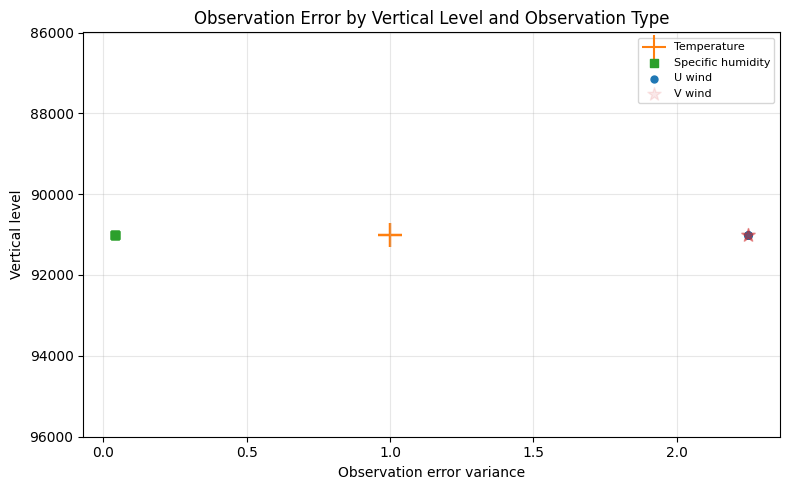

In [5]:
data_file = get_example_data("/gpfs/research/scratch/sa24m/tqprof/run2/osse_out/sys_obs/window_2015071300_2015071512/ascii_to_obs_single/obs_seq20150714")
obs_seq = obsq.ObsSequence(data_file)
df = obs_seq.df

# obs_seq.df.columns
# df

plot_df = df[["vertical", "type", "obs_err_var"]].dropna().copy()

# Convert QV error variance from (kg/kg)^2 to (g/kg)^2 for plotting only
plot_df["obs_err_var_plot"] = plot_df["obs_err_var"]
plot_df.loc[
    plot_df["type"] == "RADIOSONDE_SPECIFIC_HUMIDITY",
    "obs_err_var_plot"
] = plot_df.loc[
    plot_df["type"] == "RADIOSONDE_SPECIFIC_HUMIDITY",
    "obs_err_var"
] * 1e6

# Split by observation type
temp = plot_df[plot_df["type"] == "RADIOSONDE_TEMPERATURE"]
qv   = plot_df[plot_df["type"] == "RADIOSONDE_SPECIFIC_HUMIDITY"]
u    = plot_df[plot_df["type"] == "RADIOSONDE_U_WIND_COMPONENT"]
v    = plot_df[plot_df["type"] == "RADIOSONDE_V_WIND_COMPONENT"]

plt.figure(figsize=(8, 5))

plt.scatter(
    temp["obs_err_var_plot"], temp["vertical"],
    marker="+", s=305, color="tab:orange",
    label="Temperature"
)

plt.scatter(
    qv["obs_err_var_plot"], qv["vertical"],
    marker="s", s=35, color="tab:green",
    label="Specific humidity"
)

plt.scatter(
    u["obs_err_var_plot"], u["vertical"],
    marker="o", s=25, color="tab:blue",
    label="U wind"
)

plt.scatter(
    v["obs_err_var_plot"], v["vertical"],
    marker="*", s=100, color="tab:red",
    label="V wind", alpha=0.1
)

plt.gca().invert_yaxis()
plt.xlabel("Observation error variance")
plt.ylabel("Vertical level")
plt.title("Observation Error by Vertical Level and Observation Type")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("fig/obseq_final_15.png")

In [6]:
df

,obs_num,observation,NCEP_QC_index,linked_list,longitude,latitude,vertical,vert_unit,type,metadata,external_FO,seconds,days,time,obs_err_var
0,1,297.77000,2.0,-1 2 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_TEMPERATURE,[],[],21600,151404,2015-07-14 06:00:00,1.000000e+00
1,2,0.00073,2.0,1 3 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_SPECIFIC_HUMIDITY,[],[],21600,151404,2015-07-14 06:00:00,4.000000e-08
2,3,14.42000,2.0,2 4 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_U_WIND_COMPONENT,[],[],21600,151404,2015-07-14 06:00:00,2.250000e+00
3,4,-4.78000,2.0,3 5 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_V_WIND_COMPONENT,[],[],21600,151404,2015-07-14 06:00:00,2.250000e+00
4,5,297.64000,2.0,4 6 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_TEMPERATURE,[],[],32400,151404,2015-07-14 09:00:00,1.000000e+00
5,6,0.00039,2.0,5 7 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_SPECIFIC_HUMIDITY,[],[],32400,151404,2015-07-14 09:00:00,4.000000e-08
6,7,8.98000,2.0,6 8 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_U_WIND_COMPONENT,[],[],32400,151404,2015-07-14 09:00:00,2.250000e+00
7,8,-8.01000,2.0,7 9 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_V_WIND_COMPONENT,[],[],32400,151404,2015-07-14 09:00:00,2.250000e+00
8,9,293.95000,2.0,8 10 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_TEMPERATURE,[],[],43200,151404,2015-07-14 12:00:00,1.000000e+00
9,10,0.00000,2.0,9 11 -1,260.03,37.76,91000.0,pressure (Pa),RADIOSONDE_SPECIFIC_HUMIDITY,[],[],43200,151404,2015-07-14 12:00:00,4.000000e-08
